In [1]:
import sys
print(sys.executable)

/opt/miniconda3/envs/cfb_model/bin/python


In [75]:
from dotenv import load_dotenv
import os
import time
import cfbd
import pandas as pd
import requests
from pathlib import Path

In [67]:
load_dotenv()

API_KEY = os.environ.get("CFBD_API_KEY")

if API_KEY is None:
    raise ValueError("CFBD_API_KEY not set in environment variables")

SEASONS = list(range(2010, 2025))
OUTPUT_DIR = Path("data")
OUTPUT_DIR.mkdir(exist_ok=True)
SLEEP = 1.0

In [68]:
# API Setup
configuration = cfbd.Configuration()
configuration.access_token = API_KEY
# configuration.api_key['Authorization'] = API_KEY
configuration.api_key_prefix['Authorization'] = "Bearer"

def get_client():
    # print(cfbd.ApiClient(configuration))
    return cfbd.ApiClient(configuration)

def check_api_quota():
    with get_client() as client:
        info_api = cfbd.InfoApi(client)
        info = info_api.get_user_info()
        print(f" API quota remaining: {info.usage.calls_remaining} calls")


## Data Collection

In [69]:
# get the drives
def fetch_drives(seasons: list[int]) -> pd.DataFrame:
    print("\n[1/4] Fetching drives...")
    all_drives = []
    with get_client() as client:
        plays_api = cfbd.DrivesApi(client)
        for season in seasons:
            print(f"  Season {season}...", end=" ")
            try:
                drives = plays_api.get_drives(
                    year=season,
                    season_type="regular"
                )
                records = []
                for d in drives:
                    row = d.to_dict()
                    # Flatten start_time clock object into plain columns
                    clock = row.get("startTime") or {}
                    if hasattr(clock, "minutes"):        # still a cfbd Clock object
                        row["start_minutes"] = clock.minutes or 0
                        row["start_seconds"] = clock.seconds or 0
                    elif isinstance(clock, dict):        # already a dict
                        row["start_minutes"] = clock.get("minutes") or 0
                        row["start_seconds"] = clock.get("seconds") or 0
                    else:
                        row["start_minutes"] = 0
                        row["start_seconds"] = 0
                    records.append(row)
                for r in records:
                    r["season"] = season
                all_drives.extend(records)
                print(f"  {len(records):,} drives")
            except cfbd.ApiException as e:
                print(f"ERROR: {e}")
            time.sleep(SLEEP)

    df = pd.DataFrame(all_drives)
    print(f"  Total: {len(df):,} drives across {len(seasons)} seasons")
    return df

In [70]:
# get the games
def fetch_games(seasons: list[int]) -> pd.DataFrame:
    print("\n[2/4] Fetching games...")
    all_games = []
    with get_client() as client:
        games_api = cfbd.GamesApi(client)
        for season in seasons:
            try:
                print(f"  Season {season} ")
                games = games_api.get_games(
                    year=season,
                    season_type="regular"
                )
                records = [g.to_dict() for g in games]
                for r in records:
                    r['season'] = season
                all_games.extend(records)
                print(f"   {len(records):,} games")
            except cfbd.ApiException as e:
                print(f"ERROR: {e}")
            time.sleep(SLEEP)

    df = pd.DataFrame(all_games)
    print(f"  Total: {len(df):,} games")
    return df

In [71]:
def fetch_team_ratings(seasons: list[int]) -> pd.DataFrame:
    print("\n[3/4] Fetching team ratings...")
    sp_records = []
    elo_records = []

    with get_client() as client:
        ratings_api = cfbd.RatingsApi(client)

        for season in seasons:
            print(f"  Season {season} SP+...", end=" ")
            try:
                sp = ratings_api.get_sp(year=season)
                records = [s.to_dict() for s in sp]
                for r in records:
                    r['season'] = season
                sp_records.extend(records)
                print(f"  {len(sp_records):,} teams")
            except cfbd.ApiException as e:
                print(f"SP ERROR: {e}")
            time.sleep(SLEEP)

            print("Elo..." , end=" ")
            try:
                elo = ratings_api.get_elo(year=season)
                records = [e.to_dict() for e in elo]
                for r in records:
                    r['season'] = season
                elo_records.extend(records)
                print(f"  {len(elo_records):,} teams")
            except cfbd.ApiException as e:
                print(f"ELO ERROR: {e}")
            time.sleep(SLEEP)
    
    sp_df = pd.DataFrame(sp_records)
    elo_df = pd.DataFrame(elo_records)

    if not elo_df.empty and not sp_df.empty:
        ratings_df = sp_df.merge(elo_df[["team", "season", "elo"]], on=['team', "season"], how="left")
    else:
        ratings_df = sp_df if not sp_df.empty else elo_df

    print(f"  Total: {len(ratings_df):,} team-season stats")
    return ratings_df
    

In [72]:
# get the team stats
def fetch_team_stats(seasons: list[int]) -> pd.DataFrame:
    print("\n[4/4] Fetching team stats...")
    all_stats = []
    with get_client() as client:
        stats_api = cfbd.StatsApi(client)
        for season in seasons:
            try:
                print(f"  Season {season} ")
                stats = stats_api.get_team_stats(
                    year=season,
                )
                records = [s.to_dict() for s in stats]
                for r in records:
                    r['season'] = season
                all_stats.extend(records)
                print(f"  {len(records):,} team-stats records")
            except cfbd.ApiException as e:
                print(f"ERROR: {e}")
            time.sleep(SLEEP)

    df = pd.DataFrame(all_stats)
    print(f"  Total: {len(df):,} team-stats")
    return df

In [76]:
def fetch_ppa(seasons: list[int], api_key: str) -> pd.DataFrame:
    print("\n[5/5] Fetching PPA ratings...")
    records = []
    headers = {"Authorization": f"Bearer {api_key}"}

    for season in seasons:
        print(f"  Season {season}...", end=" ")
        try:
            response = requests.get(
                "https://api.collegefootballdata.com/ppa/teams",
                headers=headers,
                params={"year": season}
            )
            response.raise_for_status()
            data = response.json()

            for entry in data:
                row = {
                    "team":   entry.get("team"),
                    "season": season,
                }
                # flatten out the metrics
                off = entry.get("offense", {}) or {}
                row["ppa_off_overall"]    = off.get("overall")
                row["ppa_off_passing"]    = off.get("passing")
                row["ppa_off_rushing"]    = off.get("rushing")
                row["ppa_off_third_down"] = off.get("thirdDown")

                def_ = entry.get("defense", {}) or {}
                row["ppa_def_overall"]    = def_.get("overall")
                row["ppa_def_passing"]    = def_.get("passing")
                row["ppa_def_rushing"]    = def_.get("rushing")
                row["ppa_def_third_down"] = def_.get("thirdDown")

                records.append(row)

            print(f"{len(data)} teams")

        except requests.HTTPError as e:
            print(f"HTTP ERROR: {e}")
        except Exception as e:
            print(f"ERROR: {e}")

        time.sleep(SLEEP)

    df = pd.DataFrame(records)
    print(f"  Total: {len(df):,} team-season PPA records")
    return df


In [77]:
#### Load to csv's so we don't have to do this too many times
df = fetch_drives(seasons=SEASONS)
df.to_csv("data/drives.csv")

df_games = fetch_games(seasons=SEASONS)
df_games.to_csv('data/games.csv')

df_ratings = fetch_team_ratings(seasons=SEASONS)
df_ratings.to_csv('data/team_ratings.csv')

df_stats = fetch_team_stats(seasons=SEASONS)
df_stats.to_csv('data/team_stats.csv')

ppa_df = fetch_ppa(SEASONS, API_KEY)
ppa_df.to_csv("data/ppa.csv", index=False)


[1/4] Fetching drives...
  Season 2010...   19,254 drives
  Season 2011...   19,841 drives
  Season 2012...   20,700 drives
  Season 2013...   21,796 drives
  Season 2014...   21,436 drives
  Season 2015...   21,758 drives
  Season 2016...   21,436 drives
  Season 2017...   21,439 drives
  Season 2018...   21,734 drives
  Season 2019...   21,412 drives
  Season 2020...   13,506 drives
  Season 2021...   20,714 drives
  Season 2022...   34,492 drives
  Season 2023...   33,950 drives
  Season 2024...   36,619 drives
  Total: 350,087 drives across 15 seasons

[2/4] Fetching games...
  Season 2010 
   1,427 games
  Season 2011 
   1,463 games
  Season 2012 
   1,344 games
  Season 2013 
   1,496 games
  Season 2014 
   1,542 games
  Season 2015 
   1,491 games
  Season 2016 
   1,502 games
  Season 2017 
   1,505 games
  Season 2018 
   1,511 games
  Season 2019 
   1,577 games
  Season 2020 
   563 games
  Season 2021 
   2,408 games
  Season 2022 
   3,657 games
  Season 2023 
   3,595 

## Create Dataframes from CSV Files

In [3]:
pd.set_option('display.max_columns', None)
# pull in data
drives_df = pd.read_csv("data/drives.csv")
games_df = pd.read_csv("data/games.csv")
team_stats_df = pd.read_csv("data/team_stats.csv")
team_ratings_df = pd.read_csv("data/team_ratings.csv")
team_ppa_df = pd.read_csv("data/ppa.csv")

/var/folders/lp/3q2mttvj0vb2sl6053_fvc8m0000gn/T/ipykernel_11670/3753278902.py:4: DtypeWarning: Columns (0: highlights) have mixed types. Specify dtype option on import or set low_memory=False.
  games_df = pd.read_csv("data/games.csv")


In [4]:
# clean up drive results
# print(drives_df['driveResult'].unique())
drive_map = {"TD": "TD",
             'END OF HALF TD':      "TD",
             'PUNT RETURN TD':      "TD",
             'PUNT TD':             "TD",
             'RUSHING TD':          'TD',
             "FG":                  "FG",
             'FG GOOD':             "FG",
             "MISSED FG":           "MISSED_FG",
             'FG MISSED':           "MISSED_FG",

             "PUNT":                "PUNT",
             "DOWNS":               "DOWNS",

             "FUMBLE":              "TURNOVER",
             "INT":                 "TURNOVER",
             'BLOCKED PUNT':        "TURNOVER",
             "INT TD":              "TURNOVER_TD", 
             'FUMBLE TD':           "TURNOVER_TD", 
             'FUMBLE RETURN TD':    "TURNOVER_TD",
             'MISSED FG TD':        "TURNOVER_TD",
             'DOWNS TD' :           "TURNOVER_TD",

             "END OF HALF":         "END_HALF",
             'END OF GAME':         "END_GAME", 
             'END OF 4TH QUARTER':  "END_HALF" ,

             'SF':                  "SAFETY"
             }
drives_df['drive_result'] = (drives_df['driveResult'].map(drive_map).fillna("OTHER"))
drives_df['drive_result'].unique()

<StringArray>
[       'PUNT',          'TD',       'OTHER',    'END_HALF', 'TURNOVER_TD',
          'FG',    'TURNOVER',    'END_GAME',   'MISSED_FG',      'SAFETY',
       'DOWNS']
Length: 11, dtype: str

In [5]:
# bring in game features
# print(games_df.columns)
game_features = ["id", "homeTeam", "awayTeam", "neutralSite", "homePoints", "awayPoints"]
games_slim = games_df[game_features].rename(columns={'id': 'gameId'})
df = drives_df.merge(games_slim, on=['gameId'], how="left")

df["quarter_seconds_remaining"] = (df["start_minutes"] * 60) + df['start_seconds']

# Minutes remaining in game (approx): each quarter = 15 min = 900 sec
df["game_minutes_remaining"] = (
    (4 - df["startPeriod"].clip(1, 4)) * 900
    + df["quarter_seconds_remaining"]
) / 60

# set up neutralsite
df['neutralSite'] = df['neutralSite'].fillna(False).astype(int)

# set up the drive starting score differential
df['startScoreDiff'] = df['startOffenseScore'] - df['startDefenseScore']
# display(df.iloc[:, 1:])

In [6]:
#### pull the offensive and defensive SP/ELO
# display(df_ratings)
sp_cols = ["team", "season"]
off_ratings_cols = {c: f"off_{c}" for c in team_ratings_df.columns if c not in sp_cols}
off_ratings = team_ratings_df.rename(columns={**off_ratings_cols, "team": "offense"})
def_ratings = team_ratings_df.rename(columns={
    **{c: f"def_{c}" for c in team_ratings_df if c not in sp_cols}, "team": "defense"
})

# load to the main df
df = df.merge(off_ratings, on=["offense", "season"], how="left")
df = df.merge(def_ratings, on=['defense', 'season'], how='left')

# display(df.iloc[:, 1:])

In [7]:
#### pull the offensive and defensive ppa values
off_ppa_cols = ["team", "season", 'ppa_off_overall', 'ppa_off_passing', 'ppa_off_rushing', 'ppa_off_third_down']
def_ppa_cols = ["team", "season", 'ppa_def_overall', 'ppa_def_passing', 'ppa_def_rushing', 'ppa_def_third_down']
off_ratings = team_ppa_df[off_ppa_cols]
def_ratings = team_ppa_df[def_ppa_cols]

df = df.merge(off_ratings, left_on=["offense", "season"], right_on=['team', 'season'], how="left")
df = df.merge(def_ratings, left_on=["defense", "season"], right_on=['team', 'season'], how="left")

# display(df.iloc[:, 1:])

In [8]:
feature_cols = [
    "gameId", "driveNumber", "season",
    "offense", "defense",

    # Drive context
    "startYardline",
    "startPeriod",
    "game_minutes_remaining",
    "startScoreDiff",
    "isHomeOffense",
    "neutralSite",

    # Team PPA values
    "ppa_off_overall",
    "ppa_off_passing",
    "ppa_off_rushing",
    "ppa_off_third_down",
    "ppa_def_overall",
    "ppa_def_passing",
    "ppa_def_rushing",
    "ppa_def_third_down",

    # Team strength
    "off_rating",
    "def_rating",
    "off_elo",
    "def_elo",

    # Drive outcome metadata
    "yards",
    "plays",

    # Target
    "drive_result",
]

# Only keep columns that actually exist in the merged df
final_cols = [c for c in feature_cols if c in df.columns]
modeling_df = df[final_cols].copy()
modeling_df = modeling_df[~modeling_df['drive_result'].isin(['OTHER','END_GAME', 'END_HALF'])]

print(f"  Modeling dataset: {len(modeling_df):,} rows x {len(modeling_df.columns)} columns")
print(f"  Drive result distribution:")
print(modeling_df["drive_result"].value_counts(normalize=True)
        .mul(100).round(1).to_string())

modeling_df.to_csv("data/modeling_data.csv")


  Modeling dataset: 310,729 rows x 26 columns
  Drive result distribution:
drive_result
PUNT           41.7
TD             26.7
TURNOVER       11.9
FG              9.5
DOWNS           5.4
MISSED_FG       3.4
TURNOVER_TD     1.2
SAFETY          0.2


## Feature Engineering

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from pathlib import Path
import joblib

# pipeline & metrics
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import (
    classification_report, log_loss, brier_score_loss,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# models
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier


In [10]:
# set up configs
DATA_PATH = Path("data/modeling_data.csv")
MODEL_DIR = Path("models"); MODEL_DIR.mkdir(exist_ok=True)
REPORT_DIR = Path("reports"); REPORT_DIR.mkdir(exist_ok=True)

RANDOM_SEED = 42
TEST_SIZE = .2
VAL_SEASON = 2024

OUTCOME_CATEGORIES = ['PUNT', 'TD', 'TURNOVER', 'FG', 'DOWNS', 'MISSED_FG', 'END_HALF', 'END_GAME', 'TURNOVER_TD', 'OTHER', 'END_FOUR', 'SAFETY']
FEATURE_COLS_OLD = [
    # Drive context
    "startYardline",
    "startPeriod",
    'game_minutes_remaining',
    "startScoreDiff",
    "isHomeOffense",
    "neutralSite",

    # Team PPA values
    "ppa_off_overall",
    "ppa_off_passing",
    "ppa_off_rushing",
    "ppa_off_third_down",
    "ppa_def_overall",
    "ppa_def_passing",
    "ppa_def_rushing",
    "ppa_def_third_down",

    # Team strength
    "off_rating",
    "def_rating",
    "off_elo",
    "def_elo"
]

FEATURE_COLS = [
        # Drive context
    "startYardline",
    "startPeriod",
    'game_minutes_remaining',
    "startScoreDiff",
    "isHomeOffense",
    "neutralSite",

    # Team PPA performance diffs
    "ppa_overall_diff",
    "ppa_passing_diff",
    "ppa_rushing_diff",
    "ppa_third_down_diff",
    "rating_diff",
    "elo_diff"
]

TARGET = 'drive_result'

In [11]:
############ Data Loading ###############
df = pd.read_csv(DATA_PATH)
print(f"Orig DataFrame: {len(df):,} rows x {df.shape[1]} columns")

missing = df[FEATURE_COLS_OLD + [TARGET]].isnull().sum()
missing = missing[missing > 0]
print("\n Missing values: ")
print(missing.to_string())

# looks like a bunch of d2 schools which is fine considering 
# as they won't make the playoffs...so I'm just dropping those rows for now
display(df[df['off_rating'].isnull()]['offense'].unique())

# drop those rows
df = df.dropna().copy()

print(f"New DataFrame: {len(df):,} rows x {df.shape[1]} columns")
missing = df[FEATURE_COLS_OLD + [TARGET]].isnull().sum()
missing = missing[missing > 0]
if not missing.empty:
    print("\n Missing values: ")
    print(missing.to_string())

# calculated differences
df["ppa_overall_diff"]   = df["ppa_off_overall"]   + df["ppa_def_overall"]
df["ppa_passing_diff"]   = df["ppa_off_passing"]   + df["ppa_def_passing"]
df["ppa_rushing_diff"]   = df["ppa_off_rushing"]   + df["ppa_def_rushing"]
df["ppa_third_down_diff"]= df["ppa_off_third_down"]+ df["ppa_def_third_down"]
df["rating_diff"]        = df["off_rating"]        - df["def_rating"]
df["elo_diff"]           = df["off_elo"]           - df["def_elo"]



Orig DataFrame: 310,729 rows x 27 columns

 Missing values: 
ppa_off_overall       57534
ppa_off_passing       57534
ppa_off_rushing       57534
ppa_off_third_down    57534
ppa_def_overall       56702
ppa_def_passing       56702
ppa_def_rushing       56702
ppa_def_third_down    56702
off_rating            57811
def_rating            56986
off_elo               57811
def_elo               56986


<StringArray>
[               'North Dakota',                      'Towson',
                'Presbyterian',               'Norfolk State',
    'Southeast Missouri State',                'Rhode Island',
                     'Hampton',                 'Florida A&M',
          'Eastern Washington',                'SE Louisiana',
 ...
             'Hanover College',                     'Catawba',
            'Point University',        'Ave Maria University',
                 'Sioux Falls',           'Black Hills State',
          'Central State (OH)',          'Central Washington',
                   'Roosevelt', 'Georgetown College Kentucky']
Length: 205, dtype: str

New DataFrame: 235,786 rows x 27 columns


In [12]:
############### Preprocessing ###############
X = df[FEATURE_COLS].copy()
# X_2 = df[FEATURE_COLS].copy()

# clean field position
if "startYardline" in X.columns:
    X['startYardline'] = X["startYardline"].clip(1, 99)

# encode target labels
le = LabelEncoder()
y = le.fit_transform(df[TARGET])

print(f"Features used ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"Target Classes: {list(le.classes_)}")

Features used (12): ['startYardline', 'startPeriod', 'game_minutes_remaining', 'startScoreDiff', 'isHomeOffense', 'neutralSite', 'ppa_overall_diff', 'ppa_passing_diff', 'ppa_rushing_diff', 'ppa_third_down_diff', 'rating_diff', 'elo_diff']
Target Classes: ['DOWNS', 'FG', 'MISSED_FG', 'PUNT', 'SAFETY', 'TD', 'TURNOVER', 'TURNOVER_TD']


## Feature Selection

Checking for the existance of multi-collinearity prior to running separate models.

It's clear that there exists collinearity in several of the PPA and Elo ratings which isn't a surprise as they are all trying to measure some level of team performance. Need to handle this issue by either scaling data prior to certain models that are prone to issue with multi-collinearity effects, or perform feature selection.

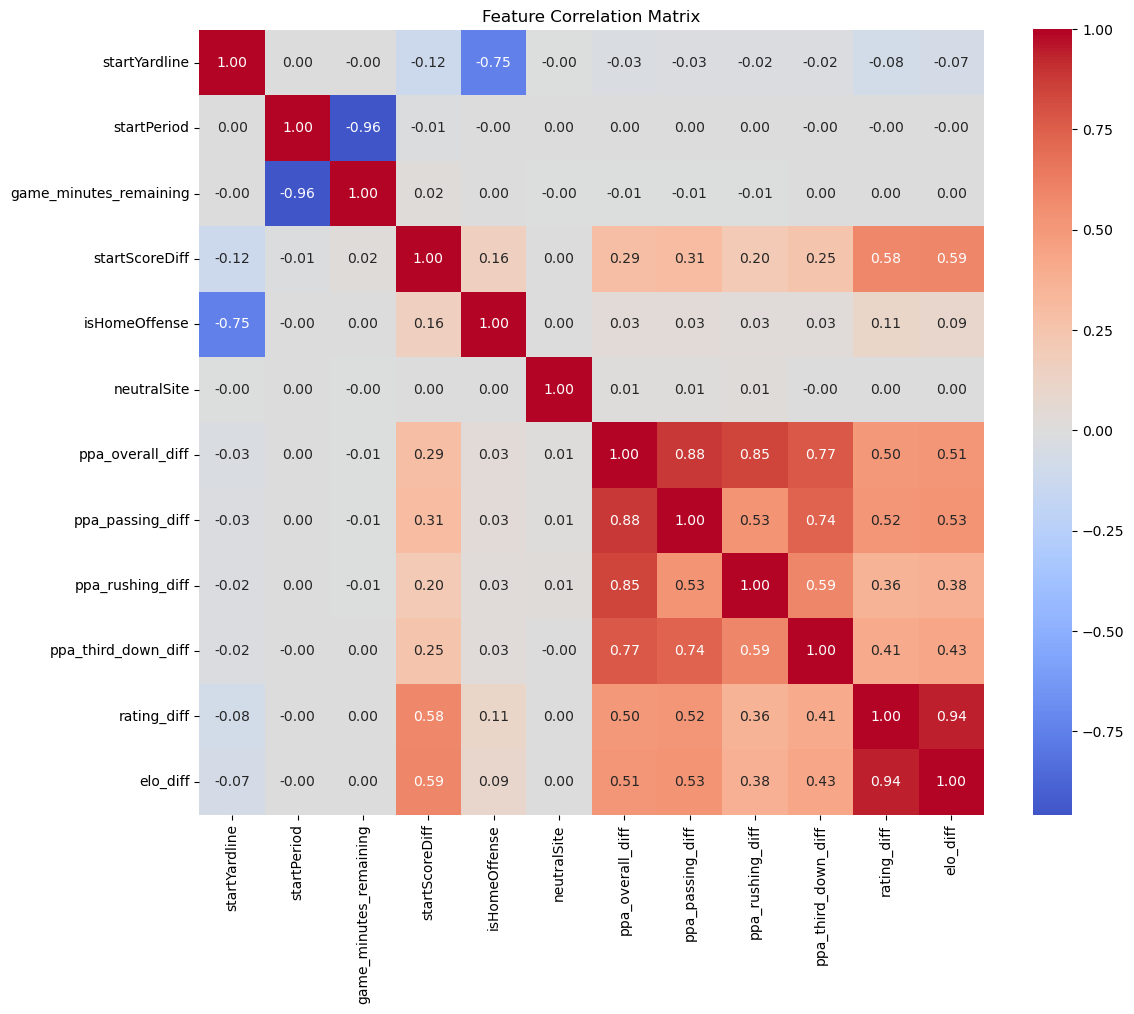

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# taking a look at correlation matrix
corr_matrix = X.corr()

# plot the matrix
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("reports/correlation_matrix.png", dpi=150)
plt.show()

Calculating mutual information scores below as they are strong at capturing linear and non-linear information for both regression and classification problems. From what we can see, neutralsite is by far the variable with the least MI and should be considered for dropping. ppa_def and ppa_off_third_down both seem relatively low as well below 0.15. Several performance metrics seem to naturally have strong scores: off_elo, ppa_off_overall, startScoreDiff, ppa_def_overall, def_elo. Good baseline understanding.

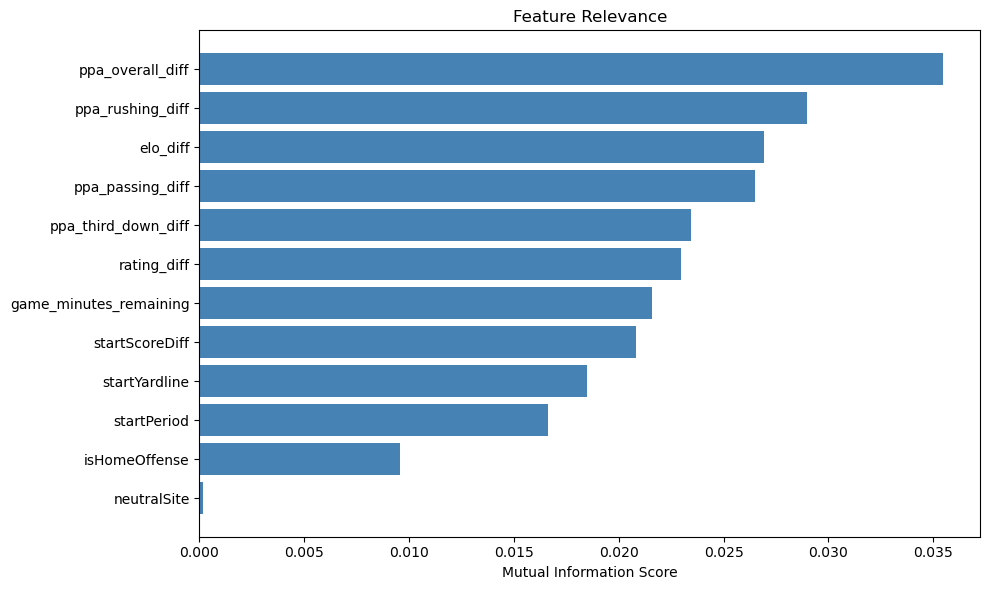

In [14]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import MinMaxScaler

# set up scaler for mutual information
scaler = MinMaxScaler()
X_scaled_min_max = scaler.fit_transform(X)

# run mutual information
mi_scores = mutual_info_classif(
    X_scaled_min_max, y,
    random_state=42
)

# set up dataframe
mi_df = pd.DataFrame({
    "feature": FEATURE_COLS,
    "mutual_info": mi_scores
}).sort_values("mutual_info")

# plot the MI scores
plt.figure(figsize=(10, 6))
plt.barh(mi_df["feature"], mi_df["mutual_info"], color="steelblue")
plt.xlabel("Mutual Information Score")
plt.title("Feature Relevance")
plt.tight_layout()
plt.savefig("reports/mutual_information.png", dpi=150)

Perform recursive feature selection using RFECV from scikit learn. We use logistic regression model as our base model for the classification problem. In addition, we ran it using kfold=5 cross validation. From the results...we can see that the optimal number of features is 10. neutralSite are both eliminated. This agrees with what we see in the above mutual information score.


Optimal number of features: 11

Selected features: ['startYardline', 'startPeriod', 'game_minutes_remaining', 'startScoreDiff', 'isHomeOffense', 'ppa_overall_diff', 'ppa_passing_diff', 'ppa_rushing_diff', 'ppa_third_down_diff', 'rating_diff', 'elo_diff']
Eliminated features: ['neutralSite']


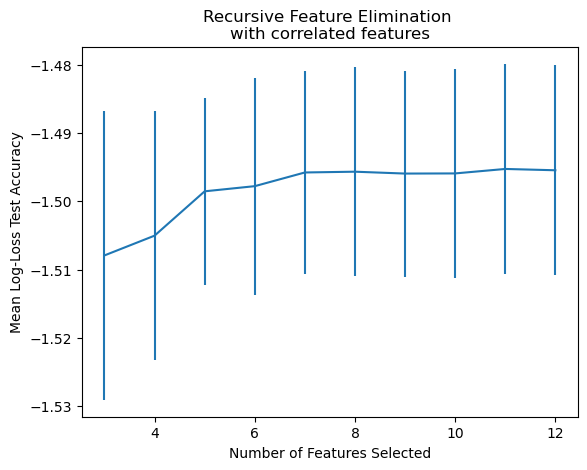

In [15]:
from sklearn.feature_selection import RFECV

# set up scaler for log regression
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# configure RFECV with log reg and cv with 5 folds
rfe = RFECV(
    estimator=LogisticRegression(
        # multi_class="multinomial",
        max_iter=1000,
        random_state=42
    ),
    step=1,
    cv=StratifiedKFold(n_splits=5),
    scoring="neg_log_loss",
    n_jobs=-1,
    min_features_to_select=3
)
rfe.fit(X_scaled, y)

# get the selected features and print
selected_features = [f for f, s in zip(FEATURE_COLS, rfe.support_) if s]
eliminated_features = [f for f, s in zip(FEATURE_COLS, rfe.support_) if not s]
print(f"\nOptimal number of features: {rfe.n_features_}")
print(f"\nSelected features: {selected_features}")
print(f"Eliminated features: {eliminated_features}")

# pull the feature number and mean log loss test score across folds
cv_results = pd.DataFrame({
    key: value
    for key, value in rfe.cv_results_.items()
    if key in ["n_features", "mean_test_score", "std_test_score"]
})

# plot the mean log loss test score
plt.figure()
plt.xlabel("Number of Features Selected")
plt.ylabel("Mean Log-Loss Test Accuracy")
plt.errorbar(
    x=cv_results["n_features"],
    y=cv_results["mean_test_score"],
    yerr=cv_results["std_test_score"],
)
plt.title("Recursive Feature Elimination \nwith correlated features")
plt.savefig("reports/rfecv_plot.png", dpi=150)
plt.show()

Load the test data for monte carlo simulation. It is just 2024 data an brings in just the team elo, sp, and ppa numbers. Will need to calculate the diff values in the simulation steps.

In [16]:
# load the test data for the 2024 season and montecarlo use
ratings_test = team_ratings_df[team_ratings_df['season']== 2024][['year', 'team', 'rating', 'elo']]
ratings_test['off_rating'] = ratings_test['rating']
ratings_test['off_elo'] = ratings_test['elo']
ratings_test = ratings_test.rename(columns={'year': 'season','rating': 'def_rating', 'elo': 'def_elo'})
# ppa numbers for 2024 season 
ppa_test = team_ppa_df[team_ppa_df['season'] == 2024]
# ppa_test = ppa_test.drop(columns=['ppa_off_third_down','ppa_def_third_down'])
# merge the ratings and ppa data
test_data = ratings_test.merge(ppa_test, on=['season', 'team'], how='left')
# find the unique seasons and teams in the df
unique_teams = modeling_df[modeling_df['season'] == 2024]['offense'].unique()
test_data = test_data[test_data['team'].isin(unique_teams)]
test_data.to_csv("test_data/test_data_2024.csv", index=False)

# reconfigure features columns without neutralsite and third down ppa
X = X.drop(columns=['neutralSite'])
FEATURE_COLS = [c for c in FEATURE_COLS if c not in ['neutralSite']]


## Model Training & Selection

In [17]:
# Set up train/test split based on year
test_mask = df['season'] == VAL_SEASON
train_mask = df['season'] < VAL_SEASON

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]
print(f"Training Data has {len(X_train)} rows")
print(f"Testing Data has {len(X_test)} rows")

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=RANDOM_SEED, stratify=y_train
)

Training Data has 219206 rows
Testing Data has 16580 rows


In [18]:
# neat little trick here. Going to use DummyClassifier to get the baseline score neccessary in models
# https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html
dummy = DummyClassifier(strategy='stratified', random_state=RANDOM_SEED)
dummy.fit(X_train, y_train)
dummy_probs = dummy.predict_proba(X_test)
baseline_11 = log_loss(y_test, dummy_probs)
print(f"Baseline log-loss (stratified dummy): {baseline_11:.4f}")

Baseline log-loss (stratified dummy): 26.6523


### Nearest Neighbors Model

In [19]:
knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

param_dist = {
    "knn__n_neighbors": [5, 15, 30],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2],  # 1 = Manhattan, 2 = Euclidean
    "knn__leaf_size": [20, 40, 60]
}

knn_random = RandomizedSearchCV(
    knn_pipe,
    param_distributions=param_dist,
    n_iter=15,
    scoring="neg_log_loss",   # 🔑 key for your project
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

knn_random.fit(X_tr, y_tr)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
[CV] END knn__leaf_size=60, knn__n_neighbors=5, knn__p=2, knn__weights=uniform; total time=  12.6s
[CV] END knn__leaf_size=60, knn__n_neighbors=5, knn__p=2, knn__weights=uniform; total time=  12.3s
[CV] END knn__leaf_size=60, knn__n_neighbors=5, knn__p=2, knn__weights=uniform; total time=  12.8s
[CV] END knn__leaf_size=60, knn__n_neighbors=15, knn__p=2, knn__weights=uniform; total time=  19.4s
[CV] END knn__leaf_size=60, knn__n_neighbors=30, knn__p=2, knn__weights=distance; total time=  24.2s
[CV] END knn__leaf_size=60, knn__n_neighbors=30, knn__p=2, knn__weights=distance; total time=  24.2s
[CV] END knn__leaf_size=60, knn__n_neighbors=30, knn__p=2, knn__weights=distance; total time=  24.7s
[CV] END knn__leaf_size=40, knn__n_neighbors=5, knn__p=1, knn__weights=distance; total time=  30.3s
[CV] END knn__leaf_size=40, knn__n_neighbors=5, knn__p=1, knn__weights=distance; total time=  30.9s
[CV] END knn__leaf_size=40, knn__n_neig

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'knn__leaf_size': [20, 40, ...], 'knn__n_neighbors': [5, 15, ...], 'knn__p': [1, 2], 'knn__weights': ['uniform', 'distance']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_log_loss'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.

In [20]:
best_knn = knn_random.best_estimator_

print("Best Params:", knn_random.best_params_)
print("Best CV Log-Loss:", -knn_random.best_score_)

knn_probs = best_knn.predict_proba(X_val)
knn_logloss = log_loss(y_val, knn_probs)

print(f"KNN Test Log-Loss: {knn_logloss:.4f}")

Best Params: {'knn__weights': 'uniform', 'knn__p': 1, 'knn__n_neighbors': 30, 'knn__leaf_size': 20}
Best CV Log-Loss: 2.6637638340596
KNN Test Log-Loss: 2.6579


In [21]:
knn_calibrated = CalibratedClassifierCV(best_knn, method="isotonic", cv=5)
knn_calibrated.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2","Pipeline(step...rs=30, p=1))])"
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fi

### Naive Bayes Model

In [22]:
nb_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("nb", GaussianNB())
])

param_dist = {
    "nb__var_smoothing": np.logspace(-11, -7, 5)
}

from sklearn.model_selection import RandomizedSearchCV

nb_random = RandomizedSearchCV(
    nb_pipe,
    param_distributions=param_dist,
    n_iter=5,
    scoring="neg_log_loss",
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

nb_random.fit(X_tr, y_tr)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV] END ............................nb__var_smoothing=1e-11; total time=   0.3s
[CV] END ............................nb__var_smoothing=1e-11; total time=   0.3s
[CV] END ............................nb__var_smoothing=1e-11; total time=   0.3s
[CV] END ............................nb__var_smoothing=1e-10; total time=   0.3s
[CV] END ............................nb__var_smoothing=1e-10; total time=   0.3s
[CV] END ............................nb__var_smoothing=1e-09; total time=   0.3s
[CV] END ............................nb__var_smoothing=1e-10; total time=   0.4s
[CV] END ............................nb__var_smoothing=1e-09; total time=   0.3s
[CV] END ............................nb__var_smoothing=1e-09; total time=   0.4s
[CV] END ............................nb__var_smoothing=1e-08; total time=   0.3s
[CV] END ............................nb__var_smoothing=1e-08; total time=   0.2s
[CV] END ............................nb__var_smoo

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...aussianNB())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'nb__var_smoothing': array([1.e-11...e-08, 1.e-07])}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_log_loss'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold 

In [23]:
best_nb = nb_random.best_estimator_

print("Best Params:", nb_random.best_params_)
print("Best CV Log-Loss:", -nb_random.best_score_)

nb_probs = best_nb.predict_proba(X_val)
nb_logloss = log_loss(y_val, nb_probs)

print(f"Naive Bayes Test Log-Loss: {nb_logloss:.4f}")

Best Params: {'nb__var_smoothing': np.float64(1e-07)}
Best CV Log-Loss: 1.7215312405851009
Naive Bayes Test Log-Loss: 1.7079


In [24]:
nb_calibrated = CalibratedClassifierCV(best_nb, method="isotonic", cv=5)
nb_calibrated.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",Pipeline(step...t64(1e-07)))])
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit 

### Logistic Regression Model

In [25]:
logreg_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

param_dist = {
    "logreg__C": np.logspace(-3, 2, 6),   # regularization strength
    "logreg__solver": ["lbfgs", "saga"]
}

logreg_random = RandomizedSearchCV(
    logreg_pipe,
    param_distributions=param_dist,
    n_iter=10,
    scoring="neg_log_loss",
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

logreg_random.fit(X_tr, y_tr)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END ..............logreg__C=0.001, logreg__solver=lbfgs; total time=   0.9s
[CV] END ..............logreg__C=0.001, logreg__solver=lbfgs; total time=   0.9s
[CV] END ..............logreg__C=0.001, logreg__solver=lbfgs; total time=   1.0s
[CV] END ..............logreg__C=100.0, logreg__solver=lbfgs; total time=   1.3s
[CV] END ..............logreg__C=100.0, logreg__solver=lbfgs; total time=   1.5s
[CV] END ..............logreg__C=100.0, logreg__solver=lbfgs; total time=   1.7s
[CV] END ...............logreg__C=10.0, logreg__solver=lbfgs; total time=   1.7s
[CV] END ...............logreg__C=10.0, logreg__solver=lbfgs; total time=   1.4s
[CV] END ...............logreg__C=0.01, logreg__solver=lbfgs; total time=   0.8s
[CV] END ...............logreg__C=0.01, logreg__solver=lbfgs; total time=   0.9s
[CV] END ...............logreg__C=10.0, logreg__solver=lbfgs; total time=   2.0s
[CV] END ...............logreg__C=0.01, logreg__

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'logreg__C': array([1.e-03...e+01, 1.e+02]), 'logreg__solver': ['lbfgs', 'saga']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_log_loss'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default valu

In [26]:
best_logreg = logreg_random.best_estimator_

print("Best Params:", logreg_random.best_params_)
print("Best CV Log-Loss:", -logreg_random.best_score_)

logreg_probs = best_logreg.predict_proba(X_val)
logreg_logloss = log_loss(y_val, logreg_probs)

print(f"Logistic Regression Test Log-Loss: {logreg_logloss:.4f}")

Best Params: {'logreg__solver': 'saga', 'logreg__C': np.float64(1.0)}
Best CV Log-Loss: 1.4751184456585367
Logistic Regression Test Log-Loss: 1.4726


In [27]:
logreg_calibrated = CalibratedClassifierCV(best_logreg, method="isotonic", cv=5)
logreg_calibrated.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",Pipeline(step...ver='saga'))])
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit 

### Random Forest Model

In [28]:
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators": [100, 300, 500],
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", "log2"]
}

rf_random = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=5,
    scoring="neg_log_loss",
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

rf_random.fit(X_tr, y_tr)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV] END max_depth=None, max_features=log2, min_samples_leaf=5, min_samples_split=10, n_estimators=100; total time=  22.4s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=5, min_samples_split=10, n_estimators=100; total time=  22.4s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=  22.7s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=  22.7s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=5, min_samples_split=10, n_estimators=100; total time=  22.9s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=  22.9s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=  24.0s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_e

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_log_loss'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used

In [29]:
best_rf = rf_random.best_estimator_

print("Best Params:", rf_random.best_params_)
print("Best CV Log-Loss:", -rf_random.best_score_)

rf_probs = best_rf.predict_proba(X_val)
rf_logloss = log_loss(y_val, rf_probs)

print(f"Random Forest Test Log-Loss: {rf_logloss:.4f}")

Best Params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}
Best CV Log-Loss: 1.4485647229396064
Random Forest Test Log-Loss: 1.4360


In [30]:
rf_calibrated = CalibratedClassifierCV(best_rf, method="isotonic", cv=5)
rf_calibrated.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",RandomForestC...ndom_state=42)
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'

### XGBoost Model

In [31]:
xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=len(le.classes_),
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators": [200, 400, 600],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "min_child_weight": [1, 5, 10],
    "gamma": [0, 0.1, 0.3]
}

xgb_random = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist,
    n_iter=25,
    scoring="neg_log_loss",
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

xgb_random.fit(X_tr, y_tr)

Fitting 3 folds for each of 25 candidates, totalling 75 fits
[CV] END colsample_bytree=0.85, gamma=0.3, learning_rate=0.05, max_depth=3, min_child_weight=10, n_estimators=200, subsample=1.0; total time=   8.9s
[CV] END colsample_bytree=0.85, gamma=0.3, learning_rate=0.05, max_depth=3, min_child_weight=10, n_estimators=200, subsample=1.0; total time=   8.5s
[CV] END colsample_bytree=0.85, gamma=0.3, learning_rate=0.05, max_depth=3, min_child_weight=10, n_estimators=200, subsample=1.0; total time=   8.6s
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.05, max_depth=3, min_child_weight=5, n_estimators=200, subsample=1.0; total time=   9.2s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.05, max_depth=7, min_child_weight=5, n_estimators=200, subsample=0.85; total time=  16.5s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.05, max_depth=7, min_child_weight=5, n_estimators=200, subsample=0.85; total time=  17.0s
[CV] END colsample_bytree=1.0, gamma=0, learning_ra

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier..._class=8, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.85, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_log_loss'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used 

In [32]:
best_xgb = xgb_random.best_estimator_

print("Best Params:", xgb_random.best_params_)
print("Best CV Log-Loss:", -xgb_random.best_score_)

xgb_probs = best_xgb.predict_proba(X_val)
xgb_logloss = log_loss(y_val, xgb_probs)

print(f"XGBoost Test Log-Loss: {xgb_logloss:.4f}")

Best Params: {'subsample': 0.7, 'n_estimators': 400, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.85}
Best CV Log-Loss: 1.398669567409294
XGBoost Test Log-Loss: 1.3913


In [33]:
xgb_calibrated = CalibratedClassifierCV(best_xgb, method="isotonic", cv=5)
xgb_calibrated.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2","XGBClassifier..._class=8, ...)"
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[flo

## ECE and Brier Score Calculations

Expected Calibration Error measures whether a probability prediction of 70% is correct 70% of the time. It takes the probability prediction for the top predicted class for each record and puts the predictions in bins. For example, there might be bins of 0-10%, 11-20%, etc. Then it takes the difference of the average predicted probability of each bin from the accuracy of each bin, and takes a weighted average across all bins. If a model is overconfident or underconfident in it's prediction, ECE will suffer. The largest drawback of ECE, it only measures the health of the probability prediction for the top predicted class. But for our simulation, we want healthy probability predictions for all 8 classes. 

This is where the Brier Score comes in. Brier score calculates the squared difference between a predicted probability for each class minus the one-hot encoded actual outcome divided by the number of classes. Consequently, it will punish overconfidence and underconfidence in the probability predictions for each class. 

Before evaluating these metrics, we applied Calibration to each model to improve probability estimates. We use Sklearn's CalibratedClassifierCV to use isotonic regression to pull the probability estimates closer to reality. Along with using Log-Loss as the training objective for each model, calibration produces probability distributions closer to reality. 

In [34]:
def compute_ece(y_true, y_probs, n_bins=10):
    # Only use top-class probabilities
    y_pred = np.argmax(y_probs, axis=1)
    confidences = np.max(y_probs, axis=1)
    accuracies = (y_pred == y_true)
    
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    
    for i in range(n_bins):
        bin_lower = bins[i]
        bin_upper = bins[i + 1]
        
        in_bin = (confidences > bin_lower) & (confidences <= bin_upper)
        
        if np.sum(in_bin) > 0:
            bin_acc = np.mean(accuracies[in_bin])
            bin_conf = np.mean(confidences[in_bin])
            ece += np.abs(bin_acc - bin_conf) * np.sum(in_bin) / len(y_true)
            
    return ece

In [35]:
def compute_brier(y_true, y_probs):
    ohe = OneHotEncoder(sparse_output=False)
    y_true_oh = ohe.fit_transform(y_true.reshape(-1, 1))
    
    return np.mean(np.sum((y_probs - y_true_oh) ** 2, axis=1))

In [36]:
def evaluate_model(model, X, y):
    y_probs = model.predict_proba(X)
    
    return{
        "LogLoss": log_loss(y, y_probs),
        "ECE": compute_ece(y, y_probs),
        "Brier": compute_brier(y, y_probs)
    }

There are a few things to note from the results. Each of the Calibrated models actually helps to lower the Log-Loss metric. Even when Log-Loss penalizes over and under confidence in a model's prediction, it only considers the quality of prediction for the true outcome. Although, the Calibrated Random Forest had the lowest Log-Loss, it does so at the expense of ECE - showing that the model is poorly calibrated for the the top predicted class. So, we chose to use the Calibrated XGBoost model because it has a more balanced ECE and more importantly a lower Brier score than every model except for the Calibrated Random Forest. 

In [37]:
results = []

models = {
    "KNN": knn_random.best_estimator_,
    "KNN (Calibrated)": knn_calibrated,
    "Naive Bayes": nb_random.best_estimator_,
    "Naive Bayes (Calibrated)": nb_calibrated,
    "Logistic Regression": logreg_random.best_estimator_,
    "Logistic Regression (Calibrated)": logreg_calibrated,
    "Random Forest": rf_random.best_estimator_,
    "Random Forest (Calibrated)": rf_calibrated,
    "XGBoost": xgb_random.best_estimator_,
    "XGBoost (Calibrated)": xgb_calibrated
}

for name, model in models.items():
    metrics = evaluate_model(model, X_val, y_val)
    metrics["Model"] = name
    results.append(metrics)
    
results_df = pd.DataFrame(results)
results_df = results_df[["Model", "LogLoss", "ECE", "Brier"]]

display(results_df)

,Model,LogLoss,ECE,Brier
0,KNN,2.657943,0.022458,0.692386
1,KNN (Calibrated),1.389344,0.044371,0.663751
2,Naive Bayes,1.707875,0.155809,0.771091
3,Naive Bayes (Calibrated),1.474045,0.010156,0.701054
4,Logistic Regression,1.472597,0.005143,0.699412
5,Logistic Regression (Calibrated),1.473931,0.015703,0.700626
6,Random Forest,1.435998,0.012374,0.680118
7,Random Forest (Calibrated),1.072734,0.183926,0.530762
8,XGBoost,1.391344,0.008194,0.664579
9,XGBoost (Calibrated),1.355472,0.022023,0.654177


## Load best performing model to joblib

In [64]:
joblib.dump(xgb_calibrated, "models/xgb_calibrated.pkl")
joblib.dump(le, "models/label_encoder.pkl")

['models/label_encoder.pkl']

## Classification Report and Confusion Matrix

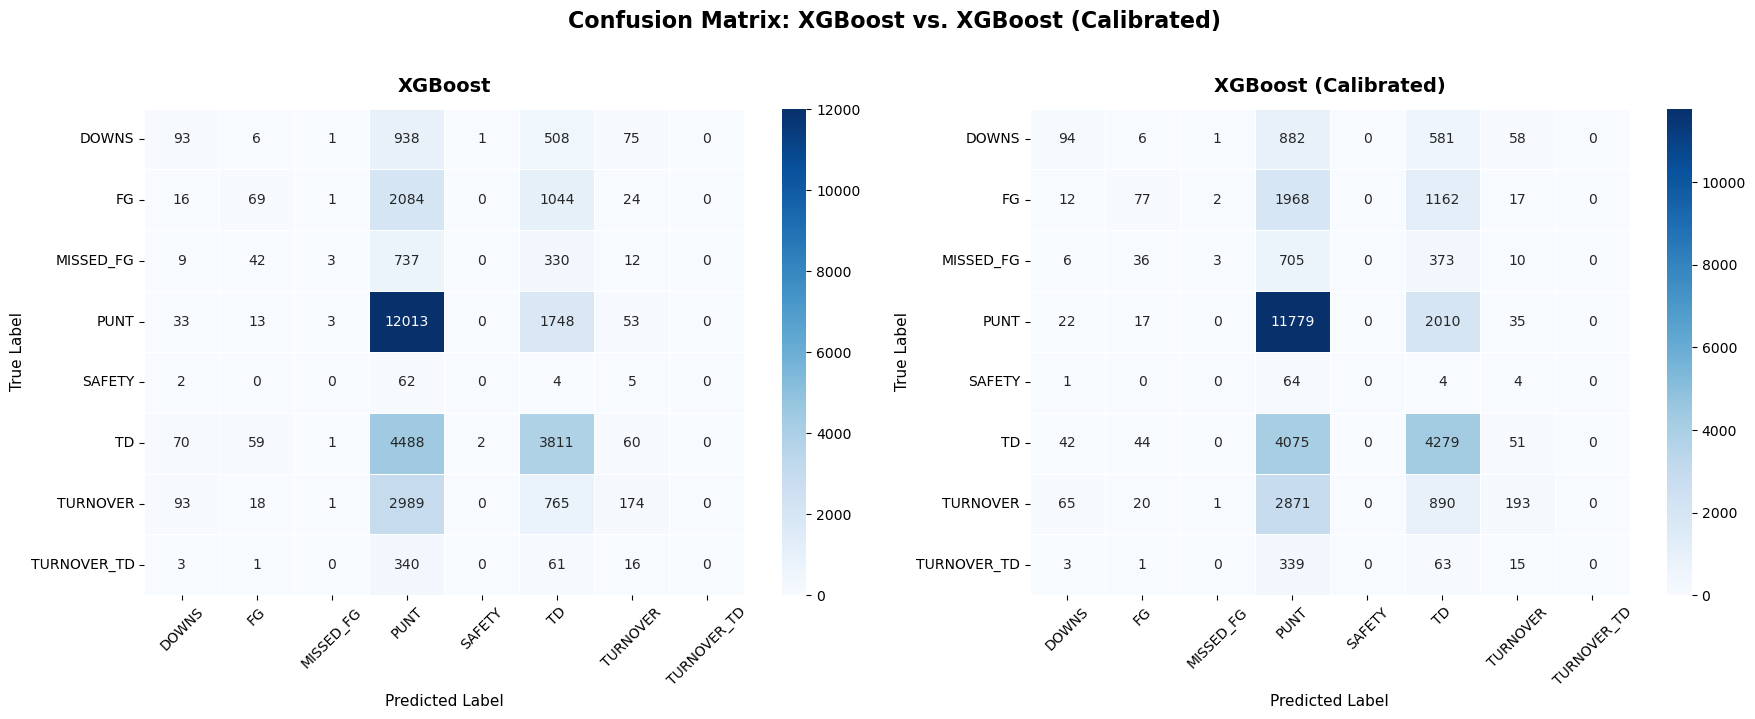

Saved to reports/confusion_matrix.png


In [42]:
# Class labels
class_labels = ['DOWNS', 'FG', 'MISSED_FG', 'PUNT', 'SAFETY', 'TD', 'TURNOVER', 'TURNOVER_TD']

# Generate predictions for both models
y_pred_xgb = best_xgb.predict(X_val)
y_pred_xgb_cal = xgb_calibrated.predict(X_val)

# Compute confusion matrices
cm_xgb = confusion_matrix(y_val, y_pred_xgb)
cm_xgb_cal = confusion_matrix(y_val, y_pred_xgb_cal)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, cm, title in zip(axes, 
                          [cm_xgb, cm_xgb_cal], 
                          ['XGBoost', 'XGBoost (Calibrated)']):
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_labels,
        yticklabels=class_labels,
        ax=ax,
        linewidths=0.5
    )
    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('Confusion Matrix: XGBoost vs. XGBoost (Calibrated)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Save to reports folder
reports_dir = './reports'
os.makedirs(reports_dir, exist_ok=True)
plt.savefig(os.path.join(reports_dir, 'confusion_matrix.png'), 
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved to reports/confusion_matrix.png")

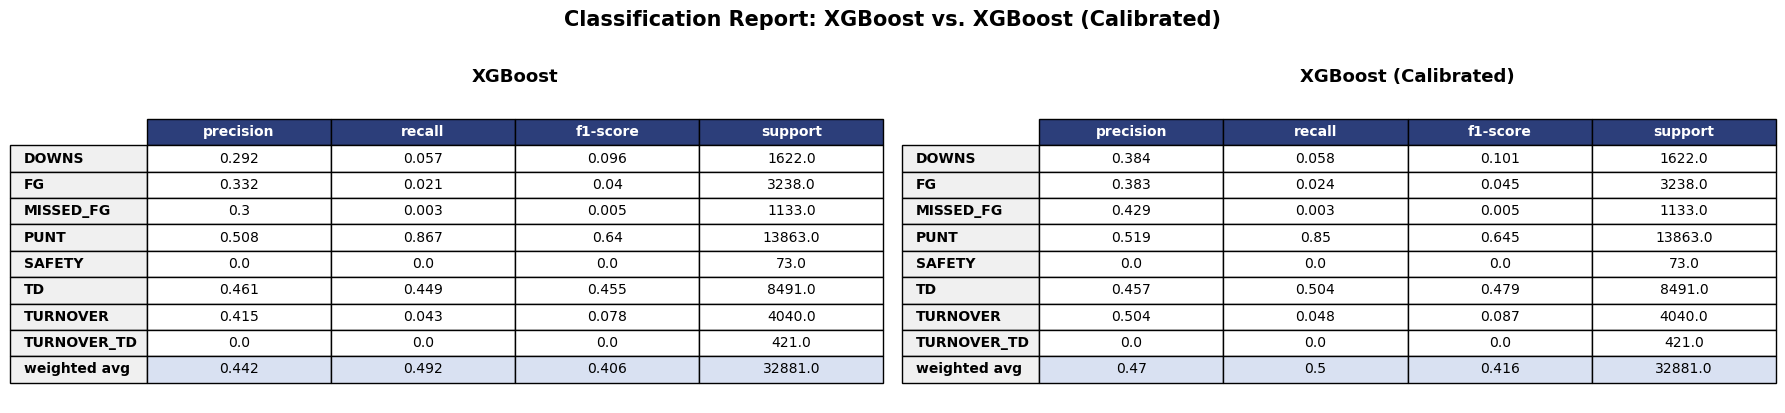

Saved to reports/classification_report.png


In [54]:
# take a look at your classification report
# decent accuracy. Biggest concern is really the FG percentage

# Generate classification reports as dictionaries
report_xgb = classification_report(y_val, y_pred_xgb, target_names=le.classes_, output_dict=True, zero_division=0)
report_xgb_cal = classification_report(y_val, y_pred_xgb_cal, target_names=le.classes_, output_dict=True, zero_division=0)

# Convert to DataFrames, keep only per-class rows + weighted avg
def report_to_df(report):
    df = pd.DataFrame(report).T
    df = df.loc[list(le.classes_) + ['weighted avg']]
    df = df[['precision', 'recall', 'f1-score', 'support']]
    df['support'] = df['support'].astype(int)
    df = df.round(3)
    return df

# Plot side by side as tables
fig, axes = plt.subplots(1, 2, figsize=(18, 4))

for ax, df, title in zip(axes,
                          [df_xgb, df_xgb_cal],
                          ['XGBoost', 'XGBoost (Calibrated)']):
    ax.axis('off')
    table = ax.table(
        cellText=df.values,
        rowLabels=df.index,
        colLabels=df.columns,
        cellLoc='center',
        loc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.6)
    
    # Style header row
    for j in range(len(df.columns)):
        table[0, j].set_facecolor('#2c3e7a')
        table[0, j].set_text_props(color='white', fontweight='bold')

    # Style row labels
    for i in range(1, len(df.index) + 1):
        table[i, -1].set_facecolor('#f0f0f0')
        table[i, -1].set_text_props(fontweight='bold')

    # Highlight weighted avg row
    for j in range(len(df.columns)):
        table[len(df.index), j].set_facecolor('#d9e1f2')

    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)

plt.suptitle('Classification Report: XGBoost vs. XGBoost (Calibrated)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()

# Save to reports folder
reports_dir = './reports'
os.makedirs(reports_dir, exist_ok=True)
plt.savefig(os.path.join(reports_dir, 'classification_report.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved to reports/classification_report.png")


Calibration curves show

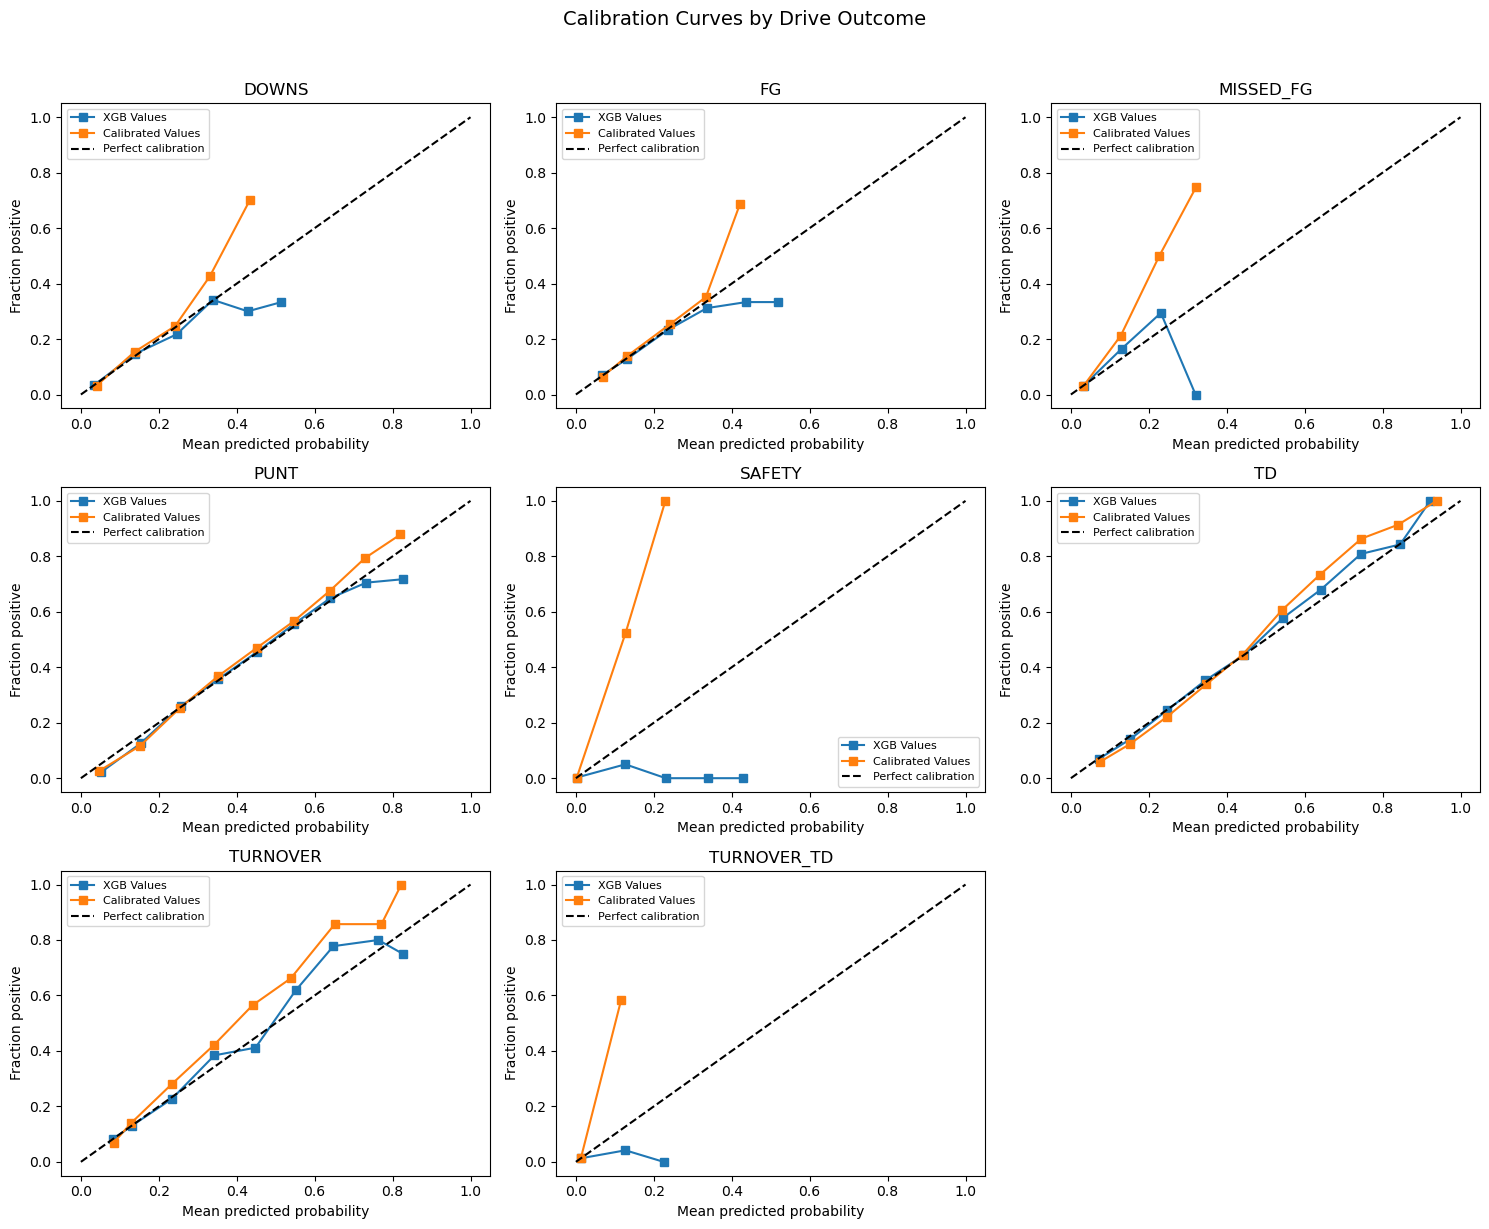

Saved to reports/calibration_curve.png


In [66]:
cal_probs = xgb_calibrated.predict_proba(X_val)
n_classes = len(le.classes_)
cols = min(3, n_classes)
rows = (n_classes + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
axes = axes.flatten() if n_classes > 1 else [axes]

for i, cls in enumerate(le.classes_):
    y_binary = (y_val == i).astype(int)
    fraction_pos, mean_pred = calibration_curve(y_binary, xgb_probs[:, i], n_bins=10)
    f_pos, m_pred = calibration_curve(y_binary, cal_probs[:, i], n_bins=10)
    axes[i].plot(mean_pred, fraction_pos, "s-", label="XGB Values")
    axes[i].plot(m_pred, f_pos, "s-", label="Calibrated Values")
    axes[i].plot([0, 1], [0, 1], "k--", label="Perfect calibration")
    axes[i].set_title(f"{cls}")
    axes[i].set_xlabel("Mean predicted probability")
    axes[i].set_ylabel("Fraction positive")
    axes[i].legend(fontsize=8)

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Calibration Curves by Drive Outcome", fontsize=14, y=1.02)
plt.tight_layout()

# Save to reports folder
reports_dir = './reports'
os.makedirs(reports_dir, exist_ok=True)
plt.savefig(os.path.join(reports_dir, 'calibration_curve.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved to reports/calibration_curve.png")
